# Candidate-Signature Consensus (CSC): do symbol hints help model-agreement checks?

**Experiment 10, iteration 4 (T6-P).** This experiment tests a *gold-free* faithfulness metric for natural-language→first-order-logic (NL→FOL) translations.

**Candidate-Signature Consensus (CSC).** Peers from *other* model families translate the same sentence. Each peer is shown the **candidate's own symbol list** (predicate and constant names with arities). A peer *agrees* when its formula is **z3-equivalent** to the candidate. Symbol names match case-insensitively; no aligner is used.

- `c_csc = 1 − (#peers equivalent to the candidate) / (#parseable peers)`. **Higher means the candidate is more likely an error.**
- Cueing the peers with the candidate's vocabulary removes the renaming problem of free consensus. The cost is **anchoring**: a peer may copy a wrong symbol from the list and so endorse an error.

**What actually ran (deviation D-BUDGET).** The run-wide OpenRouter budget was already exhausted, so *no CSC peers were generated*. The experiment instead scored zero-cost arms. This notebook reproduces the main one, **SIGPROXY**: the exp-7 **SIG** outputs of the same peer families. Those peers were cued with the closed *template* signature on R_COMP sentences. The notebook also runs the **labelled SIG check**, the within-template AUROC of `c_proxy`. The full run reports 0.930 [0.916, 0.943], against 0.952 for the 9-peer `c_score_sig` and 0.587 for a disguised cheap LLM judge.

**About this notebook.** The artifact's `method.py` is a thin orchestrator that runs `src/*.py` stages as subprocesses. Its code appears below as written. For the stages that can run here (`score` and `analysis`, R_COMP SIG part), the notebook copies the library functions they call (`vendor_e/fol.py`, `peer_text.py`, `repair_census.py`, `csc_lib.py`, `csc_score.py`, `csc_analysis.py`, `auc_tools.py`) into the cells, only lightly adapted. The functions run in-process on a 100-row subset: 10 sentences × 10 systems.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru — NOT pre-installed on Colab, always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')

# numpy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- original method.py imports ---
from __future__ import annotations

import argparse
import asyncio
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- imports of the vendored library code used below (csc_lib / peer_text / fol / repair_census / csc_score / auc_tools) ---
import hashlib
import itertools
import json
import random
import re
import time
import types
from collections import Counter, defaultdict

import numpy as np
import z3

# --- notebook-only: visualisation ---
import matplotlib.pyplot as plt

sys.setrecursionlimit(20000)

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_Jhw6i0bFXdo3/round-4/experiment-10/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(len(data["examples"]), "SIG rows;", len({e["sentence_id"] for e in data["examples"]}), "sentences;",
      dict(Counter(e["label"] for e in data["examples"])))

Exp-7 R_COMP SIG rows (template-signature-cued translations by 10 systems / 8 families) for 10 sentences; source of the SIGPROXY peers and of the labelled SIG check in experiment 10 (CSC).
100 SIG rows; 10 sentences; {'ERROR': 41, 'UNPARSEABLE': 1, 'CORRECT': 56, 'READING_CHOICE': 1, 'OFF_SIGNATURE': 1}


## Configuration

Every tunable parameter is set here. The demo values are small; the original full-run values are in the comments.

In [5]:
# ---- tunable parameters -------------------------------------------------------------------------
N_SENTENCES = 10     # sentences of the mini set to score (each has 10 SIG rows). Original: all 221 R_COMP sentences (2,210 rows)
Z3_MS = 2000         # z3 timeout (ms) per equivalence check; UNKNOWN counts as NOT equivalent.  Original: 2000
B = 2000             # cluster-bootstrap replicates for the AUROC CI (sentences resampled within template). Original: 2000
SEED = 0             # bootstrap seed. Original: 0
WITH_GRADED = False  # graded CSC (claim-unit F1) needs the full peer_text entailment machinery -> not part of this demo
RUN_STAGES = "score,analysis"  # the '--stage' argument of method.py; only these two can run inside the notebook

## 1. The orchestrator: `method.py`

This is the artifact's entry point, as written. It sets up logging, gives each stage a subprocess command (`STAGES`), fixes the stage order (`ORDER`), and runs the paid API stages (`pilot`, `peers`) only after a 1-token budget probe. Two notebook adaptations:

- `ROOT` becomes the working directory, because a notebook has no `__file__`.
- The rotating file log sink is dropped.

The subprocess commands in `STAGES` need the full repository (`src/`, `data/`). Section 5 swaps in the in-notebook versions of `score` and `analysis`.

In [6]:
ROOT = Path.cwd()  # notebook: Path(__file__).resolve().parent -> cwd
PY = sys.executable
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")   # file sink of the original (not needed here)


def run(args: list[str], timeout: int = 7200) -> None:
    logger.info("$ " + " ".join(args))
    r = subprocess.run(args, cwd=ROOT, timeout=timeout)
    if r.returncode != 0:
        raise RuntimeError(f"stage failed ({r.returncode}): {' '.join(args)}")


def key_has_budget() -> bool:
    sys.path.insert(0, str(ROOT / "src"))
    import or_client
    try:
        ok, msg = asyncio.run(or_client.probe())
    except Exception as ex:  # noqa: BLE001 - network errors mean 'no budget now'
        ok, msg = False, f"{type(ex).__name__}: {ex}"
    logger.info(f"key probe: {msg}")
    return ok


STAGES = {
    "views": [[PY, "src/views.py"]],
    "tests": [[PY, "-m", "pytest", "-q", "tests/test_csc_lib.py", "-p", "no:cacheprovider"]],
    "pilot": [[PY, "src/peers_run.py", "pilot"]],
    "prereg": [[PY, "src/csc_prereg.py"]],
    "peers": [[PY, "src/peers_run.py", "all"]],
    "local": [[PY, "src/local_peers.py"]],
    "score": [[PY, "src/csc_score.py"], [PY, "src/csc_score.py", "--local"]],
    "typing": [[PY, "src/csc_typing.py", "--which", "oracle,csc,proxy,free3"]],
    "analysis": [[PY, "src/csc_analysis.py"], [PY, "src/csc_tables.py"]],
    "manifest": [[PY, "src/csc_manifest.py"]],
    "output": [[PY, "src/csc_output.py"]],
    "rederive": [[PY, "tests/rederive.py"]],
}
ORDER = ["views", "tests", "pilot", "prereg", "peers", "local", "score", "typing", "manifest", "analysis", "output", "rederive"]
API = {"pilot", "peers"}

## 2. The FOL parser and z3 equivalence (`vendor_e/fol.py`, the dataset-E parser)

The library parses formulas in Unicode FOLIO/MALLS notation (`∀ ∃ ¬ ∧ ∨ → ↔ ⊕`) into a tuple AST, for example `("all", "x", ("imp", ("atom", "P", ("x",)), ...))`. It then decides equivalence with z3 over an uninterpreted sort `U`: `equivalent(e1, e2)` checks whether `e1 ↔ e2` is valid. A string that fails to parse is a **coverage failure**. It is counted, never dropped. The code is copied unchanged, keeping only the functions CSC uses.

In [7]:
TOK = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|\(|\)|,|[A-Za-z_][A-Za-z0-9_'\-]*)")
OPS = {"↔": "iff", "⊕": "xor", "→": "imp", "∨": "or", "∧": "and"}
IDENT = re.compile(r"^[A-Za-z_][A-Za-z0-9_'\-]*$")
PREC = {"iff": 1, "imp": 2, "xor": 3, "or": 3, "and": 4}  # FIX (gen_art_dataset_1): ⊕ moved to the ∨ level, binds tighter than →


def tokenize(s: str) -> list[str]:
    s = s.replace("⇒", "→").replace("<->", "↔").replace("->", "→").replace("&", "∧").replace("|", "∨")  # FIX: <-> before ->
    s = s.replace("~", "¬").replace("!", "¬").replace("¬", "¬").replace("−", "-")
    pos, out = 0, []
    s = s.strip().rstrip(".")
    while pos < len(s):
        m = TOK.match(s, pos)
        if not m:
            raise ValueError(f"bad char at {pos}: {s[pos:pos+10]!r}")
        out.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    return out


class Parser:
    def __init__(self, s: str):
        self.t = tokenize(s)
        self.i = 0

    def peek(self):
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x=None):
        tok = self.peek()
        if x is not None and tok != x:
            raise ValueError(f"expected {x} got {tok}")
        self.i += 1
        return tok

    def parse(self):
        e = self.expr(0)
        if self.peek() is not None:
            raise ValueError(f"trailing {self.t[self.i:]}")
        return e

    def expr(self, minp):
        lhs = self.unary()
        while self.peek() in OPS and PREC[OPS[self.peek()]] > minp - 1 and PREC[OPS[self.peek()]] >= minp:
            op = OPS[self.eat()]
            # → is right-assoc, others left-assoc
            nxt = PREC[op] if op == "imp" else PREC[op] + 1
            rhs = self.expr(nxt)
            lhs = (op, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok in ("∀", "∃"):
            self.eat()
            vs = [self.eat()]
            while self.peek() not in ("(", "¬", "∀", "∃") and self.peek() is not None and re.match(r"^[a-z][a-z0-9]*$", self.peek() or "") and not self._is_atom_start():
                vs.append(self.eat())
            body = self.unary()  # FOLIO/MALLS convention: a quantifier binds the next group/atom/quantifier
            for v in reversed(vs):
                body = ("all" if tok == "∀" else "ex", v, body)
            return body
        if tok == "(":
            self.eat("(")
            e = self.expr(0)
            self.eat(")")
            return e
        name = self.eat()
        if name is None or not IDENT.match(name):  # FIX (gen_art_dataset_1): truncated input used to yield atom None
            raise ValueError(f"expected identifier, got {name!r}")
        if self.peek() == "(":
            self.eat("(")
            args = [self.eat()]
            while self.peek() == ",":
                self.eat(",")
                args.append(self.eat())
            self.eat(")")
            if any(a is None or not IDENT.match(a) for a in args):
                raise ValueError(f"bad argument list {args!r}")
            return ("atom", name, tuple(args))
        return ("atom", name, ())  # propositional atom

    def _is_atom_start(self):
        return self.i + 1 < len(self.t) and self.t[self.i + 1] == "("


def parse(s: str):
    return Parser(s).parse()


def preds(e, acc=None):
    acc = {} if acc is None else acc
    if e[0] == "atom":
        acc[f"{e[1]}/{len(e[2])}"] = len(e[2])  # key by name/arity: arity clashes are distinct symbols
    elif e[0] in ("all", "ex"):
        preds(e[2], acc)
    elif e[0] == "not":
        preds(e[1], acc)
    else:
        preds(e[1], acc)
        preds(e[2], acc)
    return acc


U = z3.DeclareSort("U")


def to_z3(e, env, P):
    k = e[0]
    if k in ("all", "ex"):
        v = z3.Const(e[1], U)
        env2 = dict(env)
        env2[e[1]] = v
        b = to_z3(e[2], env2, P)
        return z3.ForAll([v], b) if k == "all" else z3.Exists([v], b)
    if k == "not":
        return z3.Not(to_z3(e[1], env, P))
    if k == "atom":
        args = [env.get(a, z3.Const("c_" + a, U)) for a in e[2]]
        f = P[f"{e[1]}/{len(e[2])}"]
        return f(*args) if args else f
    a, b = to_z3(e[1], env, P), to_z3(e[2], env, P)
    return {"and": lambda: z3.And(a, b), "or": lambda: z3.Or(a, b), "imp": lambda: z3.Implies(a, b),
            "iff": lambda: a == b, "xor": lambda: z3.Xor(a, b)}[k]()


def mkpred(name, n):
    name = name.replace("/", "_a")
    return z3.Function(name, *([U] * n), z3.BoolSort()) if n else z3.Bool(name)


def valid(c, ms=3000):
    s = z3.Solver()
    s.set("timeout", ms)
    s.add(z3.Not(c))
    r = s.check()
    return True if r == z3.unsat else (False if r == z3.sat else None)


def equivalent(e1, e2, ms=5000):
    ar = {**preds(e1), **preds(e2)}
    P = {q: mkpred(q, m) for q, m in ar.items()}
    return valid(to_z3(e1, {}, P) == to_z3(e2, {}, P), ms)


# the original code imports this file as module `fol` / `EFOL`
EFOL = types.SimpleNamespace(parse=parse, preds=preds, to_z3=to_z3, mkpred=mkpred, valid=valid, equivalent=equivalent)

## 3. Canonical strings and random-model fingerprints (`peer_text.py`, `repair_census.py`)

`eq_prepped` avoids a z3 call when it can, in two ways:
- **Canonical string**: alpha-normalise bound variables to `v0, v1, …` and print the formula. Identical strings are equivalent.
- **Random-model fingerprint** (`fp`): evaluate the formula in 24 pseudo-random interpretations over a 3-element domain. Different fingerprints prove *non*-equivalence, since the formulas disagree on a finite model.

Only if both shortcuts are inconclusive does z3 decide. Functions are copied unchanged.

In [8]:
# ---------------- peer_text.py (subset) ----------------
BINSYM = {"iff": "↔", "xor": "⊕", "imp": "→", "or": "∨", "and": "∧"}


def parse_fol(s: str | None):
    """Dataset-E parser. Returns the AST or None (unparseable = coverage failure, never silently dropped)."""
    if s is None or not str(s).strip():
        return None
    try:
        return EFOL.parse(str(s))
    except (ValueError, IndexError, RecursionError, TypeError):
        return None


def to_str(e) -> str:
    """Fully parenthesised Unicode rendering; parse_fol(to_str(e)) == e."""
    k = e[0]
    if k == "atom":
        return f"{e[1]}({', '.join(e[2])})" if e[2] else e[1]
    if k in ("all", "ex"):
        return f"{'∀' if k == 'all' else '∃'}{e[1]} ({to_str(e[2])})"
    if k == "not":
        return f"¬({to_str(e[1])})" if e[1][0] not in ("atom", "not") else f"¬{to_str(e[1])}"
    return f"({to_str(e[1])} {BINSYM[k]} {to_str(e[2])})"


def alpha(e, env=None, ctr=None):
    """Alpha-normalise bound variables to v0, v1, ... in order of their binders (canonical strings; unique binders)."""
    env = {} if env is None else env
    ctr = [0] if ctr is None else ctr
    k = e[0]
    if k == "atom":
        return ("atom", e[1], tuple(env.get(a, a) for a in e[2]))
    if k in ("all", "ex"):
        nv = f"v{ctr[0]}"
        ctr[0] += 1
        return (k, nv, alpha(e[2], {**env, e[1]: nv}, ctr))
    if k == "not":
        return ("not", alpha(e[1], env, ctr))
    return (k, alpha(e[1], env, ctr), alpha(e[2], env, ctr))


def canon(e) -> str:
    return to_str(alpha(e))


PT = types.SimpleNamespace(parse_fol=parse_fol, to_str=to_str, alpha=alpha, canon=canon)


# ---------------- vendor_c/repair_census.py (subset) ----------------
def atoms(e, acc=None):
    acc = [] if acc is None else acc
    if e[0] == "atom":
        acc.append(e)
    elif e[0] in ("all", "ex"):
        atoms(e[2], acc)
    elif e[0] == "not":
        atoms(e[1], acc)
    else:
        atoms(e[1], acc); atoms(e[2], acc)
    return acc


def bound_vars(e, acc=None):
    acc = set() if acc is None else acc
    if e[0] in ("all", "ex"):
        acc.add(e[1]); bound_vars(e[2], acc)
    elif e[0] == "not":
        bound_vars(e[1], acc)
    elif e[0] != "atom":
        bound_vars(e[1], acc); bound_vars(e[2], acc)
    return acc


def symbols(e):
    bv = bound_vars(e)
    P, C = {}, set()
    for a in atoms(e):
        P[(a[1], len(a[2]))] = True
        for x in a[2]:
            if x not in bv:
                C.add(x)
    return set(P), C


# ---------------------------------------------------------------- random-model fingerprint (necessary condition)
SEEDS = list(range(24))


def ev(e, m, env, dom, seed):
    k = e[0]
    if k == "atom":
        args = tuple(env[x] if x in env else (hash((seed, "c", x)) % dom) for x in e[2])
        return (hash((seed, e[1], len(e[2]), args)) >> 3) & 1 == 1
    if k == "all":
        return all(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "ex":
        return any(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "not":
        return not ev(e[1], m, env, dom, seed)
    a, b = ev(e[1], m, env, dom, seed), ev(e[2], m, env, dom, seed)
    return {"and": a and b, "or": a or b, "imp": (not a) or b, "iff": a == b, "xor": a != b}[k]


def fp(e):
    return tuple(ev(e, None, {}, 3, s) for s in SEEDS)


RC = types.SimpleNamespace(atoms=atoms, bound_vars=bound_vars, symbols=symbols, fp=fp)

## 4. The CSC metric (`csc_lib.py`)

This is the core of the experiment. The `Z3_MS` default now comes from the config cell. The functions:

- `extract_signature`: the candidate's symbol list, as `(name, arity)` pairs for predicates and constants.
- `symbols_block`: the hint appended to each peer's prompt, a deterministic shuffle of that list. It is only used to *show* the cue here; no API calls are made.
- `prep` / `eq_prepped`: lower-case every symbol, then compare in three steps: canonical string, then fingerprint, then z3. The result is `True`, `False` or `None` (UNKNOWN, meaning z3 timed out).
- `consensus_score`: **binary CSC**, `c = 1 − agree/used`. With fewer than 2 parseable peers the score is 0.5 (`csc_insufficient_peers`). An unparseable candidate scores 1.0 (`UNPARSEABLE`).
- `csc_multi_score`: a peer also endorses when its corroborated *second reading* (`alt_fol`) matches the candidate.
- `peer_majority`: the peers' majority equivalence class, used later for typed repair.
- `peer_assignment`: K3 is the first three peer families that differ from the candidate's family. K4 is all four peers, used only when the candidate comes from a non-peer family.

In [9]:
PEERS = [("deepseek/deepseek-v3.2", "deepseek", {"reasoning": {"enabled": False}}),
         ("microsoft/phi-4", "microsoft", {}),
         ("openai/gpt-4.1-mini", "openai", {}),
         ("qwen/qwen3-235b-a22b-2507", "qwen", {})]
PEER_MODELS = [p[0] for p in PEERS]
PEER_FAMILY = {p[0]: p[1] for p in PEERS}
PEER_EXTRA = {p[0]: p[2] for p in PEERS}
BLOCK_TEMPLATE = ("Symbols from another translation of this sentence (name/arity, random order): {items}. "
                  "Use a listed symbol wherever its name fits what the sentence says, and keep its arity. "
                  "If part of the sentence is not covered by any listed symbol, introduce a new symbol. "
                  "You need not use every listed symbol. The list is not a translation: translate the sentence "
                  "itself. Return JSON {{\"fol\": <formula>, \"alt_fol\": <a formula for a second legitimate "
                  "reading, or null>}}.")
V1B_PREFIX = "For this sentence, a symbol list IS given: "
# Z3_MS = 2000  -> set in the config cell


# ============================================================================================ parse / signature
def parse(s: str | None):
    """Dataset-E parser -> AST or None (unparseable)."""
    return PT.parse_fol(s)


def extract_signature_ast(e) -> list[tuple[str, int]]:
    """Symbols of a parsed formula: predicates (name, arity >= 0 for propositional atoms) and constants (name, 0);
    bound variables excluded. Sorted by (lower(name), arity, name); one entry per lowercase key (first spelling wins)."""
    P, C = RC.symbols(e)
    items = sorted(set(P) | {(c, 0) for c in C}, key=lambda t: (t[0].lower(), t[1], t[0]))
    out, seen = [], set()
    for n, a in items:
        k = (n.lower(), a)
        if k not in seen:
            seen.add(k)
            out.append((n, a))
    return out


def extract_signature(fol: str) -> list[tuple[str, int]]:
    """(name, arity) list of the formula's predicates and constants (arity 0), variables excluded; [] if unparseable."""
    e = parse(fol)
    return [] if e is None else extract_signature_ast(e)


def sig_lower(sig) -> list[tuple[str, int]]:
    return sorted({(n.lower(), a) for n, a in sig})


def sig_string(sig) -> str:
    return "|".join(f"{n}/{a}" for n, a in sig_lower(sig))


def symbols_block(text: str, sig, variant: str = "v1") -> str:
    """The appended CSC block; the list order is a deterministic shuffle seeded by sha1(text | canonical signature)."""
    items = [f"{n}/{a}" for n, a in sorted(sig, key=lambda t: (t[0].lower(), t[1], t[0]))]
    rng = random.Random(int(hashlib.sha1((text + "|" + sig_string(sig)).encode()).hexdigest(), 16))
    rng.shuffle(items)
    b = BLOCK_TEMPLATE.format(items=", ".join(items))
    return (V1B_PREFIX + b) if variant == "v1b" else b


# ============================================================================================ exact equivalence
def lower_ast(e, bv=frozenset()):
    """Lower-case every predicate and constant name (bound variables untouched)."""
    k = e[0]
    if k == "atom":
        return ("atom", e[1].lower(), tuple(x if x in bv else x.lower() for x in e[2]))
    if k in ("all", "ex"):
        return (k, e[1], lower_ast(e[2], bv | {e[1]}))
    if k == "not":
        return ("not", lower_ast(e[1], bv))
    return (k, lower_ast(e[1], bv), lower_ast(e[2], bv))


def prep(s: str | None):
    """Parse + lowercase -> (ast, canonical string, fingerprint) or None."""
    e = parse(s)
    if e is None:
        return None
    el = lower_ast(e)
    try:
        f = RC.fp(el)
    except RecursionError:
        f = None
    return el, PT.canon(el), f


def eq_prepped(a, b, ms: int = Z3_MS):
    """a, b from prep(). True / False / None (UNKNOWN). Canonical-string identity -> True; different random-model
    fingerprints -> False (sound: they differ on a finite model); else z3 with `ms` timeout."""
    if a is None or b is None:
        return None
    if a[1] == b[1]:
        return True
    if a[2] is not None and b[2] is not None and a[2] != b[2]:
        return False
    try:
        return EFOL.equivalent(a[0], b[0], ms=ms)
    except (Exception,):  # noqa: BLE001 - z3 exceptions / recursion on huge formulas -> UNKNOWN (counted)
        return None


def eq_exact(fa: str, fb: str, ms: int = Z3_MS):
    """Exact (no aligner) case-insensitive z3 equivalence of two formula strings: True / False / None (UNKNOWN or
    unparseable)."""
    return eq_prepped(prep(fa), prep(fb), ms)


# ============================================================================================ scores
def consensus_score(text: str, fol: str, peers: list[dict | str], mode: str = "csc", ms: int = Z3_MS,
                    _prepped: dict | None = None) -> dict:
    """Binary CSC. peers: formula strings or dicts with 'fol'. Returns {'c', 'per_peer', 'n_used', 'n_unknown',
    'n_unparseable_peers', 'status'} with c = 1 - agree/used (higher = more likely error)."""
    assert mode == "csc", mode
    pp = _prepped if _prepped is not None else {}
    cand = pp.get(fol) if fol in pp else prep(fol)
    fols = [p.get("fol") if isinstance(p, dict) else p for p in peers]
    usable = []
    n_bad = 0
    for f in fols:
        x = pp.get(f) if f in pp else prep(f)
        if x is None:
            n_bad += 1
        else:
            usable.append(x)
    if cand is None:
        return {"c": 1.0, "per_peer": [], "n_used": len(usable), "n_unknown": 0, "n_unparseable_peers": n_bad,
                "status": "UNPARSEABLE"}
    if len(usable) < 2:
        return {"c": 0.5, "per_peer": [], "n_used": len(usable), "n_unknown": 0, "n_unparseable_peers": n_bad,
                "status": "csc_insufficient_peers"}
    verd = [eq_prepped(cand, x, ms) for x in usable]
    n_true = sum(v is True for v in verd)
    return {"c": 1 - n_true / len(usable), "per_peer": verd, "n_used": len(usable),
            "n_unknown": sum(v is None for v in verd), "n_unparseable_peers": n_bad, "status": "OK"}


def csc_multi_score(text: str, fol: str, peer_records: list[dict], ms: int = Z3_MS) -> dict:
    """Multi-reading CSC. Peer p endorses iff eq(cand, p.fol) OR (p.alt parseable AND eq(cand, p.alt) AND some other
    peer q != p has eq(p.alt, q.fol) or eq(p.alt, q.alt)). Denominator = peers with a parseable fol."""
    cand = prep(fol)
    P = []
    for r in peer_records:
        f = prep(r.get("fol"))
        if f is None:
            continue
        P.append((f, prep(r.get("alt_fol")) if r.get("alt_fol") else None))
    if cand is None:
        return {"c": 1.0, "status": "UNPARSEABLE", "n_used": len(P), "n_alt_endorse": 0}
    if len(P) < 2:
        return {"c": 0.5, "status": "csc_insufficient_peers", "n_used": len(P), "n_alt_endorse": 0}
    endorse, n_alt = 0, 0
    for i, (f, alt) in enumerate(P):
        if eq_prepped(cand, f, ms) is True:
            endorse += 1
            continue
        if alt is not None and eq_prepped(cand, alt, ms) is True:
            ok = False
            for j, (g, galt) in enumerate(P):
                if j == i:
                    continue
                if eq_prepped(alt, g, ms) is True or (galt is not None and eq_prepped(alt, galt, ms) is True):
                    ok = True
                    break
            if ok:
                endorse += 1
                n_alt += 1
    return {"c": 1 - endorse / len(P), "status": "OK", "n_used": len(P), "n_alt_endorse": n_alt}


def peer_majority(peers: list[dict | str], ms: int = Z3_MS) -> dict:
    """Exact-equivalence classes among parseable peers (given in P order). Majority = a class with >= 2 members;
    a 2-2 tie (k = 4) is broken by the earliest P member. Returns {'formula' (the earliest member's fol) | None,
    'status' in {MAJORITY, NO_MAJORITY, INSUFFICIENT}, 'class_sizes'}."""
    fols = [p.get("fol") if isinstance(p, dict) else p for p in peers]
    items = [(i, f, prep(f)) for i, f in enumerate(fols)]
    items = [t for t in items if t[2] is not None]
    if len(items) < 2:
        return {"formula": None, "status": "INSUFFICIENT", "class_sizes": [len(items)] if items else []}
    classes: list[list] = []
    for t in items:
        for c in classes:
            if eq_prepped(c[0][2], t[2], ms) is True:
                c.append(t)
                break
        else:
            classes.append([t])
    best = sorted(classes, key=lambda c: (-len(c), c[0][0]))[0]
    sizes = sorted((len(c) for c in classes), reverse=True)
    if len(best) >= 2:
        return {"formula": best[0][1], "status": "MAJORITY", "class_sizes": sizes, "n_classes": len(classes)}
    return {"formula": None, "status": "NO_MAJORITY", "class_sizes": sizes, "n_classes": len(classes)}


# ============================================================================================ peers (API)
def peer_assignment(candidate_family: str | None) -> dict:
    """K3 = the first 3 members of P whose family != candidate_family; K4 = all of P only if candidate_family is not
    a P family (else None). PERTURB rows (no generator family) -> K3 = deepseek, microsoft, openai; K4 adds qwen."""
    k3 = [m for m in PEER_MODELS if PEER_FAMILY[m] != candidate_family][:3]
    k4 = list(PEER_MODELS) if candidate_family not in set(PEER_FAMILY.values()) else None
    return {"k3": k3, "k4": k4}


L = types.SimpleNamespace(consensus_score=consensus_score, csc_multi_score=csc_multi_score, peer_majority=peer_majority,
                          peer_assignment=peer_assignment, prep=prep, eq_exact=eq_exact)

### A quick look at one item

The cell below takes one sentence and shows the symbol cue CSC would append to a peer's prompt, built from the candidate's own signature. It then prints the exact-equivalence verdicts between the candidate and the SIGPROXY peers.

In [10]:
ex0 = next(e for e in data["examples"] if e["label"] == "ERROR")
print("TEXT     :", ex0["text"])
print("CANDIDATE:", ex0["candidate_fol"], f"  [{ex0['system']}, label={ex0['label']}]")
sig0 = extract_signature(ex0["candidate_fol"])
print("SIGNATURE:", sig0)
print("\nCSC cue appended to each peer prompt:\n ", symbols_block(ex0["text"], sig0))
same = [e for e in data["examples"] if e["sentence_id"] == ex0["sentence_id"] and e["slot"] in data["slot_model"]]
for p in same:
    print(f"\n  peer {data['slot_model'][p['slot']]:28s} eq={eq_exact(ex0['candidate_fol'], p['candidate_fol'])}\n    {p['candidate_fol']}")

TEXT     : Each graduate student who is criticized by their boss, who can use the left foot very efficiently, and who lives in cramped residential buildings is an employee in James's town, except if the graduate student has a temporary role at the orchestra.
CANDIDATE: ∀x (GraduateStudent(x) ∧ CriticizedBy(x, boss) ∧ UseEfficiently(x, leftFoot) ∧ LiveIn(x, crampedBuilding) → (EmployeeIn(x, jamesSTown) ∧ ¬HaveTemporaryRoleAt(x, theOrchestra)))   [G1:meta-llama/llama-3.1-8b-instruct, label=ERROR]
SIGNATURE: [('boss', 0), ('crampedBuilding', 0), ('CriticizedBy', 2), ('EmployeeIn', 2), ('GraduateStudent', 1), ('HaveTemporaryRoleAt', 2), ('jamesSTown', 0), ('leftFoot', 0), ('LiveIn', 2), ('theOrchestra', 0), ('UseEfficiently', 2)]

CSC cue appended to each peer prompt:
  Symbols from another translation of this sentence (name/arity, random order): CriticizedBy/2, theOrchestra/0, LiveIn/2, GraduateStudent/1, EmployeeIn/2, leftFoot/0, UseEfficiently/2, jamesSTown/0, HaveTemporaryRoleAt/2, bos

## 5. Stage `score` (`csc_score.py`): label-blind SIGPROXY scoring

For every SIG row, the peers are the exp-7 SIG outputs of the four peer families on the **same sentence**: G4 = deepseek, G6 = phi-4, G7 = gpt-4.1-mini, G2 = qwen. `peer_assignment` excludes the candidate's own family. A peer whose output did not parse contributes `fol = None` and is counted as an unparseable peer.

**No label is read at this stage.** The only inputs are keys, text, candidate, family and sentence id.

Notebook adaptations of `csc_score.py`:
- Only the SIG half of `build_tasks` is kept, reading from `data` instead of files.
- Tasks run in a plain loop instead of the spawn `ProcessPoolExecutor`, whose workers cannot import functions defined in a notebook.
- Results stay in memory instead of going to `results/scores_raw.jsonl`.
- Graded CSC is off (`WITH_GRADED = False`).

In [11]:
SLOT_MODEL = {"G4": "deepseek/deepseek-v3.2", "G6": "microsoft/phi-4", "G7": "openai/gpt-4.1-mini",
              "G2": "qwen/qwen3-235b-a22b-2507"}


def _csc_block(L, text, cand, peers: list[dict] | None, prefix: str, with_multi: bool, with_graded: bool) -> dict:
    out = {}
    if not peers:
        return out
    r = L.consensus_score(text, cand, peers)
    out[f"c_{prefix}"] = r["c"]
    out[f"{prefix}_status"] = r["status"]
    out[f"{prefix}_per_peer"] = r["per_peer"]
    out[f"{prefix}_n_used"] = r["n_used"]
    out[f"{prefix}_n_unknown"] = r["n_unknown"]
    out[f"{prefix}_models"] = [p["model"] for p in peers]
    if with_multi:
        m = L.csc_multi_score(text, cand, peers)
        out[f"c_{prefix}_multi"] = m["c"]
        out[f"{prefix}_multi_n_alt"] = m.get("n_alt_endorse")
    # (with_graded: graded_consensus under a 90 s SIGALRM cap in the original -- disabled in this demo)
    maj = L.peer_majority(peers)
    out[f"{prefix}_majority"] = maj["formula"]
    out[f"{prefix}_majority_status"] = maj["status"]
    out[f"{prefix}_n_classes"] = maj.get("n_classes")
    return out


def score_task(task: dict) -> dict:
    t0 = time.time()
    text, cand = task["text"], task["cand"]
    out = {"key": task["key"], "set": task["set"]}
    for arm in ("csc", "proxy", "local", "localbase"):
        if task.get(f"{arm}_k3"):
            out.update(_csc_block(L, text, cand, task[f"{arm}_k3"], arm, with_multi=True, with_graded=WITH_GRADED))
        if task.get(f"{arm}_k4"):
            b = _csc_block(L, text, cand, task[f"{arm}_k4"], arm + "_k4", with_multi=False, with_graded=False)
            out.update({k: v for k, v in b.items() if not k.endswith("_majority")})
    out["secs_csc"] = round(time.time() - t0, 3)
    return out


def _peer_dicts(fols_by_model: dict, models: list[str]) -> list[dict]:
    return [{"model": m, "fol": fols_by_model[m].get("fol"), "alt_fol": fols_by_model[m].get("alt_fol")}
            for m in models if m in fols_by_model]


def build_tasks(sig_rows: list[dict]) -> list[dict]:
    # SIGPROXY peers: exp-7 SIG outputs of the four P families, per sentence
    proxy = defaultdict(dict)
    for r in sig_rows:
        if r["slot"] in SLOT_MODEL:
            proxy[r["sentence_id"]][SLOT_MODEL[r["slot"]]] = {"fol": r["candidate_fol"] if r.get("parse_ok") else None,
                                                               "alt_fol": None}
    tasks = []
    for r in sig_rows:
        asg = L.peer_assignment(r["family"])
        t = {"key": "SIG:" + r["row_key"], "set": "SIG", "text": r["text"], "cand": r["candidate_fol"] or "",
             "sentence_id": r["sentence_id"]}
        pr = proxy.get(r["sentence_id"], {})
        t["proxy_k3"] = _peer_dicts(pr, asg["k3"])
        if asg["k4"]:
            t["proxy_k4"] = _peer_dicts(pr, asg["k4"])
        tasks.append(t)
    return tasks


SCORES: dict = {}


def stage_score() -> None:
    sids = sorted({e["sentence_id"] for e in data["examples"]})[:N_SENTENCES]
    sig_rows = [e for e in data["examples"] if e["sentence_id"] in set(sids)]
    tasks = build_tasks(sig_rows)
    todo = sorted(tasks, key=lambda t: -len(t["cand"] or ""))  # long candidates first (as in the original)
    logger.info(f"scoring: {len(tasks)} tasks ({len(sids)} sentences), sequential")
    t0 = time.time()
    for t in todo:
        try:
            res = score_task(t)
        except Exception as e:  # noqa: BLE001
            logger.error(f"task {t['key']} failed: {type(e).__name__}: {str(e)[:200]}")
            res = {"key": t["key"], "error": f"{type(e).__name__}: {str(e)[:200]}"}
        SCORES[res["key"]] = res
    logger.info(f"scoring done in {time.time() - t0:.1f}s")

## 6. Stage `analysis`, R_COMP SIG part (`csc_analysis.part4_sig` + `auc_tools.py`)

Labels come in only at this stage. Rows labelled `CORRECT` or `ERROR` are kept. The artifact's gold-referenced label is z3 equivalence to the reference under the shared template signature. `READING_CHOICE`, `OFF_SIGNATURE` and `UNPARSEABLE` rows are left out, as in the original.

- **Within-template AUROC** (`StratAUC`): pairs are formed only *inside* a template, so template difficulty cannot inflate the score. The 95% CI comes from a cluster bootstrap that resamples *sentences* within each template.
- **Comparators** are the precomputed exp-7 scores: `c_score_sig` (the 9-peer SIG consensus) and `judge_cheap_disg` (a cheap LLM judge shown a disguised formula).
- **Error/decision rates at threshold 0.5**: `e` is the share of errors endorsed (c ≤ 0.5), which should be low. `d` is the share of correct rows flagged (c > 0.5), which should also be low.

In [12]:
# ---------------- auc_tools.py (vendor_x7), unchanged ----------------
class StratAUC:
    """Precomputes per-stratum score ranks once; value(cluster_weights) is then O(n) per replicate."""

    def __init__(self, score: np.ndarray, is_err: np.ndarray, stratum: np.ndarray, cluster: np.ndarray,
                 stratum_is_cluster: bool = False):
        score = np.asarray(score, dtype=float)
        is_err = np.asarray(is_err, dtype=bool)
        self.linear = stratum_is_cluster
        self.parts = []
        for s in np.unique(stratum):
            m = stratum == s
            y = is_err[m]
            if y.all() or (~y).all():
                continue
            u, g = np.unique(score[m], return_inverse=True)
            self.parts.append((g.astype(np.int64), y, cluster[m], len(u)))

    def value(self, cw: np.ndarray | None = None) -> float:
        U = P = 0.0
        for g, y, cl, ng in self.parts:
            if cw is None:
                w = np.ones(len(g))
            else:
                w = cw[cl].astype(float)
                if self.linear:
                    w = np.sqrt(w)
            negw = np.bincount(g[~y], w[~y], minlength=ng)
            posw = np.bincount(g[y], w[y], minlength=ng)
            below = np.cumsum(negw) - negw
            U += float((posw * (below + 0.5 * negw)).sum())
            P += float(posw.sum() * negw.sum())
        return U / P if P > 0 else float("nan")


def boot_weights(cluster_stratum: np.ndarray, B: int, seed: int) -> np.ndarray:
    """(B, n_clusters) integer multiplicities; clusters resampled with replacement within their stratum (template)."""
    rng = np.random.default_rng(seed)
    n = len(cluster_stratum)
    W = np.zeros((B, n), dtype=np.int32)
    groups = [np.flatnonzero(cluster_stratum == s) for s in np.unique(cluster_stratum)]
    for b in range(B):
        for idx in groups:
            draw = rng.choice(idx, size=len(idx), replace=True)
            np.add.at(W[b], draw, 1)
    return W


def summarize(point: float, boots: np.ndarray) -> dict:
    boots = boots[~np.isnan(boots)]
    if len(boots) == 0:
        return {"est": point, "ci": [None, None], "se": None, "n_boot": 0}
    return {"est": point, "ci": [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))],
            "se": float(np.std(boots, ddof=1)), "n_boot": int(len(boots))}


def fnum(x, d=3):
    return None if x is None or (isinstance(x, float) and np.isnan(x)) else round(float(x), d)


AT = types.SimpleNamespace(StratAUC=StratAUC, boot_weights=boot_weights, summarize=summarize)
ANALYSIS: dict = {}


# ---------------- csc_analysis.part4_sig (SIG rows from `data` instead of exp-7 analysis_rows_SIG.jsonl) ----------------
def part4_sig() -> dict:
    sc = {r["key"][4:]: r for r in SCORES.values() if r["key"].startswith("SIG:")}
    rows = []
    for x in data["examples"]:
        if x["label"] not in ("CORRECT", "ERROR") or x["row_key"] not in sc:
            continue
        s = sc.get(x["row_key"], {})
        rows.append({**x, "c_proxy": s.get("c_proxy"), "c_proxy_k4": s.get("c_proxy_k4"),
                     "proxy_status": s.get("proxy_status")})
    metrics = ["c_proxy", "c_proxy_k4", "c_score_sig", "g_align", "judge_cheap_disg", "judge_cheap_orig"]

    def auc_on(rs, m, weights=None):
        sc_ = np.array([r[m] for r in rs], float)
        y = np.array([r["label"] == "ERROR" for r in rs])
        tmpl = np.array([r["template_id"] for r in rs])
        sids = sorted({r["sentence_id"] for r in rs})
        cid = {s: i for i, s in enumerate(sids)}
        cl = np.array([cid[r["sentence_id"]] for r in rs])
        return AT.StratAUC(sc_, y, tmpl, cl), cl, sids

    out = {"pool": {"n": len(rows), "n_error": sum(r["label"] == "ERROR" for r in rows),
                    "n_sentences": len({r["sentence_id"] for r in rows})}, "auroc_within_template": {}, "paired_delta": {}}
    for m in metrics:
        rs = [r for r in rows if r.get(m) is not None]
        if len(rs) < 20:
            continue
        sa, cl, sids = auc_on(rs, m)
        tmpl_of = {}
        for r in rs:
            tmpl_of[r["sentence_id"]] = r["template_id"]
        W = AT.boot_weights(np.array([tmpl_of[s] for s in sids]), B, SEED)
        bs = np.array([sa.value(W[b]) for b in range(B)])
        out["auroc_within_template"][m] = {"n": len(rs), **AT.summarize(sa.value(), bs)}
    for a in ("c_proxy",):
        for bm in ("c_score_sig", "judge_cheap_disg"):
            rs = [r for r in rows if r.get(a) is not None and r.get(bm) is not None]
            if len(rs) < 20:
                continue
            sa, cl, sids = auc_on(rs, a)
            sb, _, _ = auc_on(rs, bm)
            tmpl_of = {r["sentence_id"]: r["template_id"] for r in rs}
            W = AT.boot_weights(np.array([tmpl_of[s] for s in sids]), B, SEED)
            d = np.array([sa.value(W[b]) - sb.value(W[b]) for b in range(B)])
            out["paired_delta"][f"{a}_minus_{bm}"] = {"n": len(rs), "auroc_a": fnum(sa.value()), "auroc_b": fnum(sb.value()),
                                                      **AT.summarize(sa.value() - sb.value(), d),
                                                      "p_one_sided_le0": fnum(float(np.mean(d <= 0)), 4)}
    # e / d at c > 0.5 for proxy and c_score_sig (same rows)
    ed = {}
    for m in ("c_proxy", "c_proxy_k4", "c_score_sig"):
        rs = [r for r in rows if r.get(m) is not None]
        err = [r for r in rs if r["label"] == "ERROR"]
        cor = [r for r in rs if r["label"] == "CORRECT"]
        rec = {"n": len(rs), "e_error_endorsed": fnum(np.mean([r[m] <= 0.5 for r in err])) if err else None,
               "d_correct_flagged": fnum(np.mean([r[m] > 0.5 for r in cor])) if cor else None}
        for mr in ("weak", "strong"):
            s = [r for r in cor if r.get("matched_reading") == mr]
            rec[f"d_{mr}"] = fnum(np.mean([r[m] > 0.5 for r in s])) if s else None
            rec[f"n_correct_{mr}"] = len(s)
        ed[m] = rec
    out["e_d_at_0.5"] = ed
    out["status_counts_proxy"] = dict(Counter(r.get("proxy_status") for r in rows))
    out["_rows"] = rows
    return out


def stage_analysis() -> None:
    ANALYSIS.update(part4_sig())
    logger.info(f"analysis: pool {ANALYSIS['pool']}")

## 7. Run: `main()` from `method.py`

The loop below is the original `main()`, with two notebook changes:
- `--stage` comes from `RUN_STAGES` in the config cell.
- Each runnable stage calls its in-notebook function instead of `run(cmd)`.

The paid API stages keep the original guard. In this notebook `api_ok` is fixed to `False`, which reproduces deviation D-BUDGET: no key and no budget.

In [13]:
NOTEBOOK_STAGES = {"score": stage_score, "analysis": stage_analysis}


@logger.catch(reraise=True)
def main() -> None:
    stages = ORDER if RUN_STAGES == "all" else RUN_STAGES.split(",")
    api_ok = False  # original: key_has_budget() (1-token OpenRouter probe); the run's budget was exhausted (D-BUDGET)
    for st in stages:
        if st not in STAGES:
            raise SystemExit(f"unknown stage {st}; choose from {ORDER}")
        if st in API:
            if not api_ok:
                logger.warning(f"skipping {st}: OpenRouter key has no budget (deviation D-BUDGET)")
                continue
        if st in NOTEBOOK_STAGES:
            NOTEBOOK_STAGES[st]()
        else:
            logger.warning(f"stage {st} needs the full repository: {STAGES[st]}")
    logger.info("done")


main()

19:35:27|INFO   |scoring: 100 tasks (10 sentences), sequential


19:35:29|INFO   |scoring done in 1.4s


19:35:31|INFO   |analysis: pool {'n': 97, 'n_error': 41, 'n_sentences': 10}


19:35:31|INFO   |done


## 8. Results

The cells below check the stage-6 scores against the full run, print the AUROC table (comparing this subset with the full 2,024-row result), and plot the score distributions.

In [14]:
# (a) Agreement of the notebook's c_proxy / c_proxy_k4 with the original stage-6 scores for the same rows
n_cmp = n_same = 0
for e in data["examples"]:
    s = SCORES.get("SIG:" + e["row_key"])
    o = e.get("original_stage6_scores")
    if s is None or o is None:
        continue
    for k in ("c_proxy", "c_proxy_k4", "c_proxy_multi"):
        if o.get(k) is not None:
            n_cmp += 1
            n_same += abs((s.get(k) if s.get(k) is not None else -9) - o[k]) < 1e-9
print(f"reproduced original stage-6 SIGPROXY scores: {n_same}/{n_cmp} values identical")

# (b) AUROC table: this demo subset vs the full run (2,024 labelled rows, 221 sentences)
ref = data["reference_full_results"]
print(f"\npool (demo): {ANALYSIS['pool']}   proxy status: {ANALYSIS['status_counts_proxy']}")
print(f"\n{'metric':18s} {'demo AUROC':>11s} {'demo 95% CI':>18s} {'n':>5s} | {'full AUROC':>10s} {'full 95% CI':>18s}")
for m, v in ANALYSIS["auroc_within_template"].items():
    r = ref.get(m, {})
    ci = v["ci"]; rci = r.get("ci", [None, None])
    f = lambda x: "  -  " if x is None else f"{x:.3f}"
    print(f"{m:18s} {f(v['est']):>11s} {('[' + f(ci[0]) + ', ' + f(ci[1]) + ']'):>18s} {v['n']:>5d} | "
          f"{f(r.get('est')):>10s} {('[' + f(rci[0]) + ', ' + f(rci[1]) + ']'):>18s}")
print("\npaired deltas (demo):")
for k, v in ANALYSIS["paired_delta"].items():
    print(f"  {k:32s} {v['auroc_a']} - {v['auroc_b']} = {v['est']:+.3f}  CI [{v['ci'][0]:+.3f}, {v['ci'][1]:+.3f}]")
print("\nerror endorsed (e) / correct flagged (d) at c > 0.5:")
for k, v in ANALYSIS["e_d_at_0.5"].items():
    print(f"  {k:12s} e={v['e_error_endorsed']}  d={v['d_correct_flagged']}  (n={v['n']})")

reproduced original stage-6 SIGPROXY scores: 260/260 values identical

pool (demo): {'n': 97, 'n_error': 41, 'n_sentences': 10}   proxy status: {'OK': 97}

metric              demo AUROC        demo 95% CI     n | full AUROC        full 95% CI
c_proxy                  0.873     [0.821, 0.925]    97 |      0.930     [0.916, 0.943]
c_proxy_k4               0.876     [0.867, 0.876]    58 |      0.898     [0.878, 0.918]
c_score_sig              0.955     [0.940, 0.970]    97 |      0.952     [0.936, 0.966]
g_align                  0.989     [0.989, 0.989]    97 |      0.977     [0.970, 0.983]
judge_cheap_disg         0.583     [0.569, 0.616]    87 |      0.587     [0.550, 0.624]
judge_cheap_orig         0.486     [0.388, 0.643]    95 |      0.673     [0.636, 0.708]

paired deltas (demo):
  c_proxy_minus_c_score_sig        0.873 - 0.955 = -0.082  CI [-0.149, -0.015]
  c_proxy_minus_judge_cheap_disg   0.873 - 0.583 = +0.290  CI [+0.241, +0.314]

error endorsed (e) / correct flagged (d) at c 

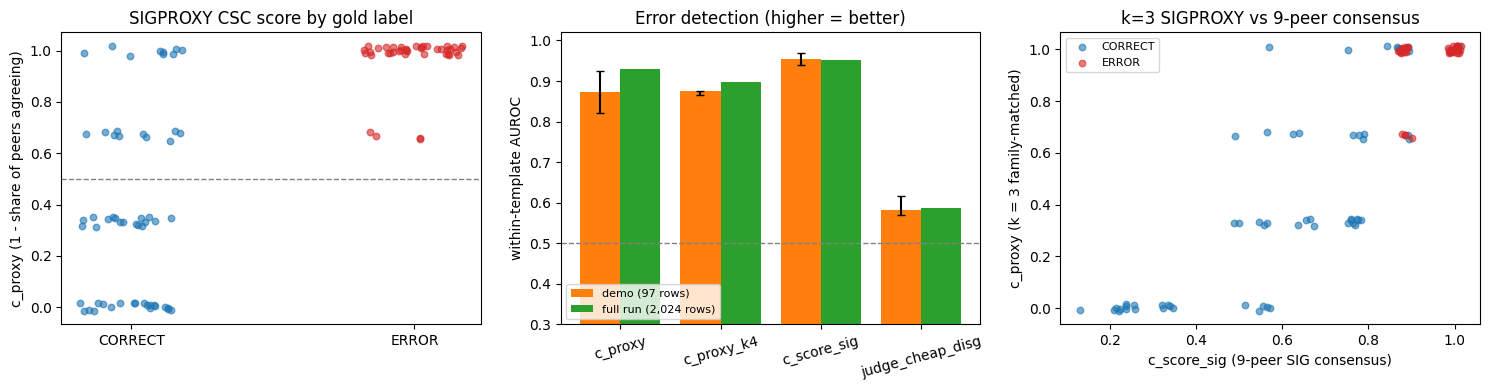

In [15]:
rows = ANALYSIS["_rows"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# left: c_proxy by gold label (jittered strip)
rng = np.random.default_rng(0)
for i, lab in enumerate(("CORRECT", "ERROR")):
    v = np.array([r["c_proxy"] for r in rows if r["label"] == lab and r["c_proxy"] is not None])
    axes[0].scatter(i + rng.uniform(-0.18, 0.18, len(v)), v + rng.uniform(-0.02, 0.02, len(v)),
                    alpha=0.6, color=("tab:blue", "tab:red")[i], s=22)
axes[0].axhline(0.5, ls="--", color="grey", lw=1)
axes[0].set_xticks([0, 1], ["CORRECT", "ERROR"]); axes[0].set_ylabel("c_proxy (1 - share of peers agreeing)")
axes[0].set_title("SIGPROXY CSC score by gold label")

# middle: AUROC demo vs full run
ms = [m for m in ("c_proxy", "c_proxy_k4", "c_score_sig", "judge_cheap_disg") if m in ANALYSIS["auroc_within_template"]]
x = np.arange(len(ms))
demo = [ANALYSIS["auroc_within_template"][m]["est"] for m in ms]
dlo = [demo[i] - (ANALYSIS["auroc_within_template"][m]["ci"][0] or demo[i]) for i, m in enumerate(ms)]
dhi = [(ANALYSIS["auroc_within_template"][m]["ci"][1] or demo[i]) - demo[i] for i, m in enumerate(ms)]
full = [ref[m]["est"] for m in ms]
axes[1].bar(x - 0.2, demo, 0.4, yerr=[dlo, dhi], capsize=3, label=f"demo ({ANALYSIS['pool']['n']} rows)", color="tab:orange")
axes[1].bar(x + 0.2, full, 0.4, label="full run (2,024 rows)", color="tab:green")
axes[1].axhline(0.5, ls="--", color="grey", lw=1)
axes[1].set_xticks(x, ms, rotation=15); axes[1].set_ylim(0.3, 1.02); axes[1].set_ylabel("within-template AUROC")
axes[1].set_title("Error detection (higher = better)"); axes[1].legend(fontsize=8, loc="lower left")

# right: c_proxy vs 9-peer c_score_sig, coloured by label
for lab, col in (("CORRECT", "tab:blue"), ("ERROR", "tab:red")):
    rs = [r for r in rows if r["label"] == lab and r["c_proxy"] is not None and r["c_score_sig"] is not None]
    axes[2].scatter([r["c_score_sig"] + rng.uniform(-0.015, 0.015) for r in rs],
                    [r["c_proxy"] + rng.uniform(-0.015, 0.015) for r in rs], alpha=0.6, color=col, s=22, label=lab)
axes[2].set_xlabel("c_score_sig (9-peer SIG consensus)"); axes[2].set_ylabel("c_proxy (k = 3 family-matched)")
axes[2].set_title("k=3 SIGPROXY vs 9-peer consensus"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

**How to read this.** `c_proxy` uses only **three** family-matched peers, each cued with the shared signature. On the full run it still ranks errors above correct translations with a within-template AUROC of about 0.93. That is close to the 9-peer consensus (0.95) and far above the cheap disguised LLM judge (0.59). The demo subset has 10 sentences, so its CIs are wide.

**Limits of this evidence:**
1. These peers were cued with a *template* signature, not the candidate's own. The headline CSC arm (own-signature cue) and its anchoring gates G3-P/G4 stay **untested**, because no API budget was left.
2. A signature cue removes the renaming problem, but it also means correct renames are flagged unless the peers are re-cued. On the full run, rename FA under a base-signature cue was 1.000.

To run the full pipeline, clone the repository and run `python method.py --stage all`. The API stages run only when the OpenRouter key has budget.